# Fine-tuning curves against the baseline, epoch by epoch

Does a pretrained start let real-data training converge faster or further than training from the initialization, and were the models still improving after 10 epochs?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

Both the baseline and every fine-tuning stage train 10 epochs on the same real training data from the same
initialization seed; only the starting weights differ (initialization versus pretrained). Epoch $e$ of a
fine-tuning stage is therefore paired with epoch $e$ of the baseline of the same axis and repetition.

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

Recorded validation and test values come from the trainer's data loaders, which re-sample the partition with
the phase's supervision sampling (positive : unlabelled = 1 : 1, with replacement); they are estimates on a
class-balanced re-sample, not plain partition means (part 0_03).

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "finetuning_curves"
AXIS = None
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

curves = table('curves')
epoch_summary = table('epoch_summary')
print('Slope epochs:', metadata['slope_epochs'], '| components:', metadata['components'])

Analysis: finetuning_curves | axis: None | stage: None | models: 310
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Slope epochs: 3 | components: ['masserstein', 'total_loss']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`finetuning_curves` reads the training histories of the baselines and of both fine-tuning stages
(train and validation splits; the test split is a single final value) and pairs them epoch by epoch.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis finetuning_curves > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Validation curves of the fine-tuned models and the baseline

### Methodology

#### Theoretical

Validation Masserstein per epoch, mean over repetitions, for every variant of one stage together with the
baseline.

#### Implementation

`curves` (long form), averaged over repetitions here.

#### Figure descriptions

Rows = stages, columns = axes; one line per variant, black = baseline; log y axis.

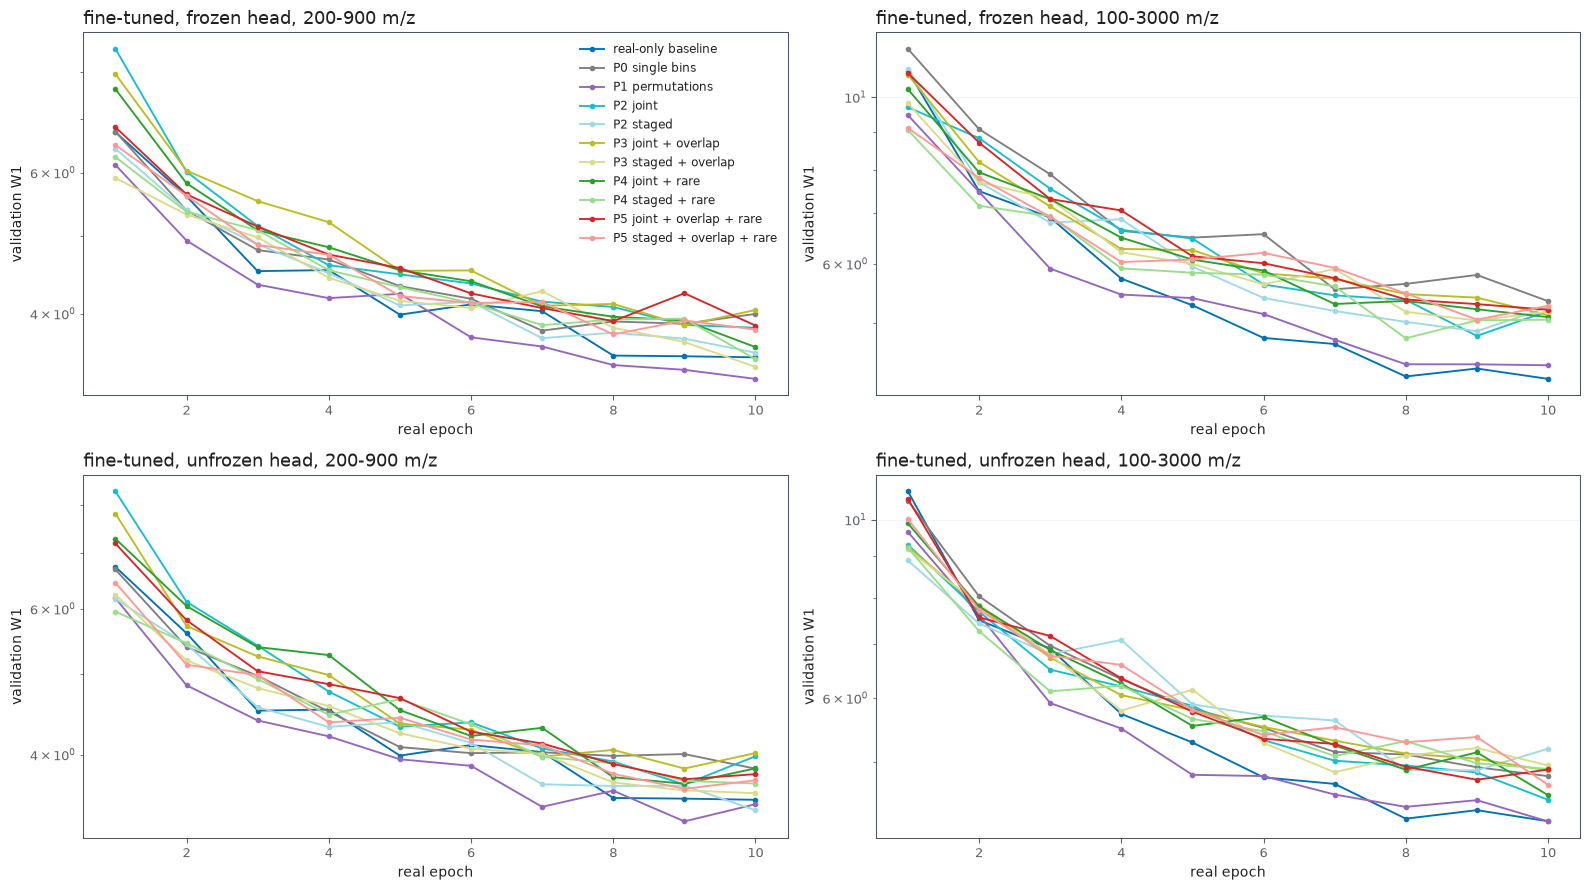

In [3]:
validation = curves[(curves.split == 'validation') & (curves.component == 'masserstein')]
means = validation.groupby(['axis', 'variant', 'stage', 'epoch'], as_index=False).value.mean()
figure, axes = plt.subplots(2, len(AXES), figsize=(8 * len(AXES), 9), dpi=theme.figure_dpi)
for row, stage in enumerate(['frozen_head', 'unfrozen_head']):
    for column, axis in enumerate(AXES):
        rows = means[(means.axis == axis) & (means.stage.isin([stage, 'real_only']))]
        figures.epoch_curves(rows, levels=ORDER, labels=VARIANT_LABELS, colors=VARIANT_COLORS, y='value', log_y=True, xlabel='real epoch',
                             ylabel='validation W1', title=f'{STAGE_LABELS[stage]}, {AXIS_LABELS[axis]}', ax=axes[row, column], theme=theme)
        if (row, column) != (0, 0):
            axes[row, column].get_legend().remove()
figure.tight_layout()

### Remarks

- axis-100-3000, frozen head: at epoch 1 the mean improvement ranges -0.752 to 1.8 (8 of 10 variants ahead of the baseline).
- axis-100-3000, unfrozen head: at epoch 1 the mean improvement ranges 0.239 to 1.95 (10 of 10 variants ahead of the baseline).
- axis-200-900, frozen head: at epoch 1 the mean improvement ranges -1.82 to 0.833 (5 of 10 variants ahead of the baseline).
- axis-200-900, unfrozen head: at epoch 1 the mean improvement ranges -1.58 to 0.788 (6 of 10 variants ahead of the baseline).

### Notes

## Paired improvement over the baseline per epoch

### Methodology

#### Theoretical

$\Delta_{r,e} = s_m(v_{r,e} - b_{r,e})$ at every epoch $e$; the curve shows whether the pretrained start is
ahead early and whether the lead survives to epoch 10.

#### Implementation

`epoch_summary` (summary over repetitions per variant, stage, component, split and epoch).

#### Figure descriptions

Rows = stages, columns = axes; line = mean improvement of validation $W_1$, band = 95 % interval, dashed =
baseline. The table gives the improvement at the last epoch for validation $W_1$ and total loss.

component                             masserstein                                                                                                                          total_loss  \
axis                                axis-100-3000                                                     axis-200-900                                                      axis-100-3000   
stage                                 frozen_head                    unfrozen_head                     frozen_head                     unfrozen_head                      frozen_head   
variant                                                                                                                                                                                 
P0_single           -1.13 [-1.79, -0.476] (+0/-5)  -0.582 [-1.06, -0.0997] (+1/-4)   -0.469 [-1.13, 0.189] (+1/-4)  -0.318 [-0.621, -0.0161] (+0/-5)     -1.65 [-2.27, -1.03] (+0/-5)   
P1_permutation      -0.18 [-0.686, 0.326] (+2/-3)  0.00171 [-0.214, 0.217] (+2/-3)   0.212 [-0.284, 0.707] (+3/-2)    0.0432 [-0.332, 0.418] (+4/-1)  -0.566 [-1.07, -0.0639] (+0/-5)   
P2_joint_base        -0.974 [-2.1, 0.146] (+0/-5)  -0.267 [-0.618, 0.0829] (+1/-4)  -0.313 [-0.69, 0.0627] (+0/-5)    -0.454 [-0.68, -0.228] (+0/-5)    -1.41 [-2.54, -0.266] (+0/-5)   
P2_staged_base      -1.04 [-1.54, -0.535] (+0/-5)    -0.974 [-1.47, -0.48] (+0/-5)  -0.0481 [-0.38, 0.283] (+3/-2)      0.101 [-0.25, 0.451] (+4/-1)     -1.53 [-2.05, -1.02] (+0/-5)   
P3_joint_overlap   -0.909 [-1.43, -0.388] (+0/-5)   -0.659 [-1.08, -0.237] (+0/-5)  -0.514 [-1.05, 0.0242] (+0/-5)     -0.489 [-1.08, 0.105] (+1/-4)     -1.3 [-1.83, -0.773] (+0/-5)   
P3_staged_overlap  -0.964 [-1.37, -0.556] (+0/-5)    -0.73 [-1.15, -0.312] (+0/-5)   0.0958 [-0.159, 0.35] (+3/-2)   -0.0651 [-0.424, 0.294] (+2/-3)     -1.46 [-1.84, -1.07] (+0/-5)   
P4_joint_rare      -0.879 [-1.79, 0.0289] (+0/-5)   -0.327 [-0.821, 0.168] (+1/-4)  -0.106 [-0.366, 0.154] (+1/-4)   -0.322 [-0.683, 0.0376] (+1/-4)    -1.27 [-2.18, -0.369] (+0/-5)   
P4_staged_rare     -0.838 [-1.25, -0.427] (+0/-5)  -0.682 [-1.32, -0.0408] (+0/-5)  0.0183 [-0.271, 0.308] (+3/-2)    -0.163 [-0.623, 0.297] (+1/-4)    -1.36 [-1.77, -0.943] (+0/-5)   
P5_joint_all       -0.995 [-1.69, -0.302] (+0/-5)    -0.674 [-1.4, 0.0573] (+0/-5)  -0.337 [-0.998, 0.323] (+1/-4)     -0.261 [-0.64, 0.118] (+1/-4)    -1.43 [-2.09, -0.772] (+0/-5)   
P5_staged_all       -1.06 [-1.71, -0.404] (+0/-5)    -0.464 [-1.25, 0.319] (+2/-3)   -0.294 [-0.818, 0.23] (+1/-4)   -0.197 [-0.436, 0.0432] (+1/-4)    -1.58 [-2.23, -0.935] (+0/-5)   

component                                                                                                               
axis                                                                    axis-200-900                                    
stage                                unfrozen_head                       frozen_head                     unfrozen_head  
variant                                                                                                                 
P0_single          -0.569 [-1.05, -0.0891] (+1/-4)    -0.887 [-1.57, -0.204] (+0/-5)  -0.317 [-0.618, -0.0164] (+0/-5)  
P1_permutation     0.00742 [-0.209, 0.224] (+2/-3)    -0.199 [-0.699, 0.301] (+2/-3)    0.0433 [-0.333, 0.419] (+4/-1)  
P2_joint_base       -0.248 [-0.601, 0.104] (+1/-4)    -0.662 [-1.03, -0.292] (+0/-5)    -0.446 [-0.671, -0.22] (+0/-5)  
P2_staged_base      -0.963 [-1.46, -0.469] (+0/-5)  -0.435 [-0.774, -0.0963] (+0/-5)     0.105 [-0.245, 0.456] (+4/-1)  
P3_joint_overlap     -0.64 [-1.06, -0.221] (+0/-5)     -0.83 [-1.38, -0.285] (+0/-5)      -0.484 [-1.08, 0.11] (+1/-4)  
P3_staged_overlap   -0.719 [-1.13, -0.304] (+0/-5)   -0.279 [-0.54, -0.0182] (+1/-4)   -0.0617 [-0.419, 0.295] (+2/-3)  
P4_joint_rare       -0.307 [-0.803, 0.189] (+1/-4)   -0.437 [-0.702, -0.172] (+0/-5)   -0.314 [-0.674, 0.0455] (+1/-4)  
P4_staged_rare      -0.67 [-1.31, -0.0295] (+0/-5)   -0.36 [-0.671, -0.0499] (

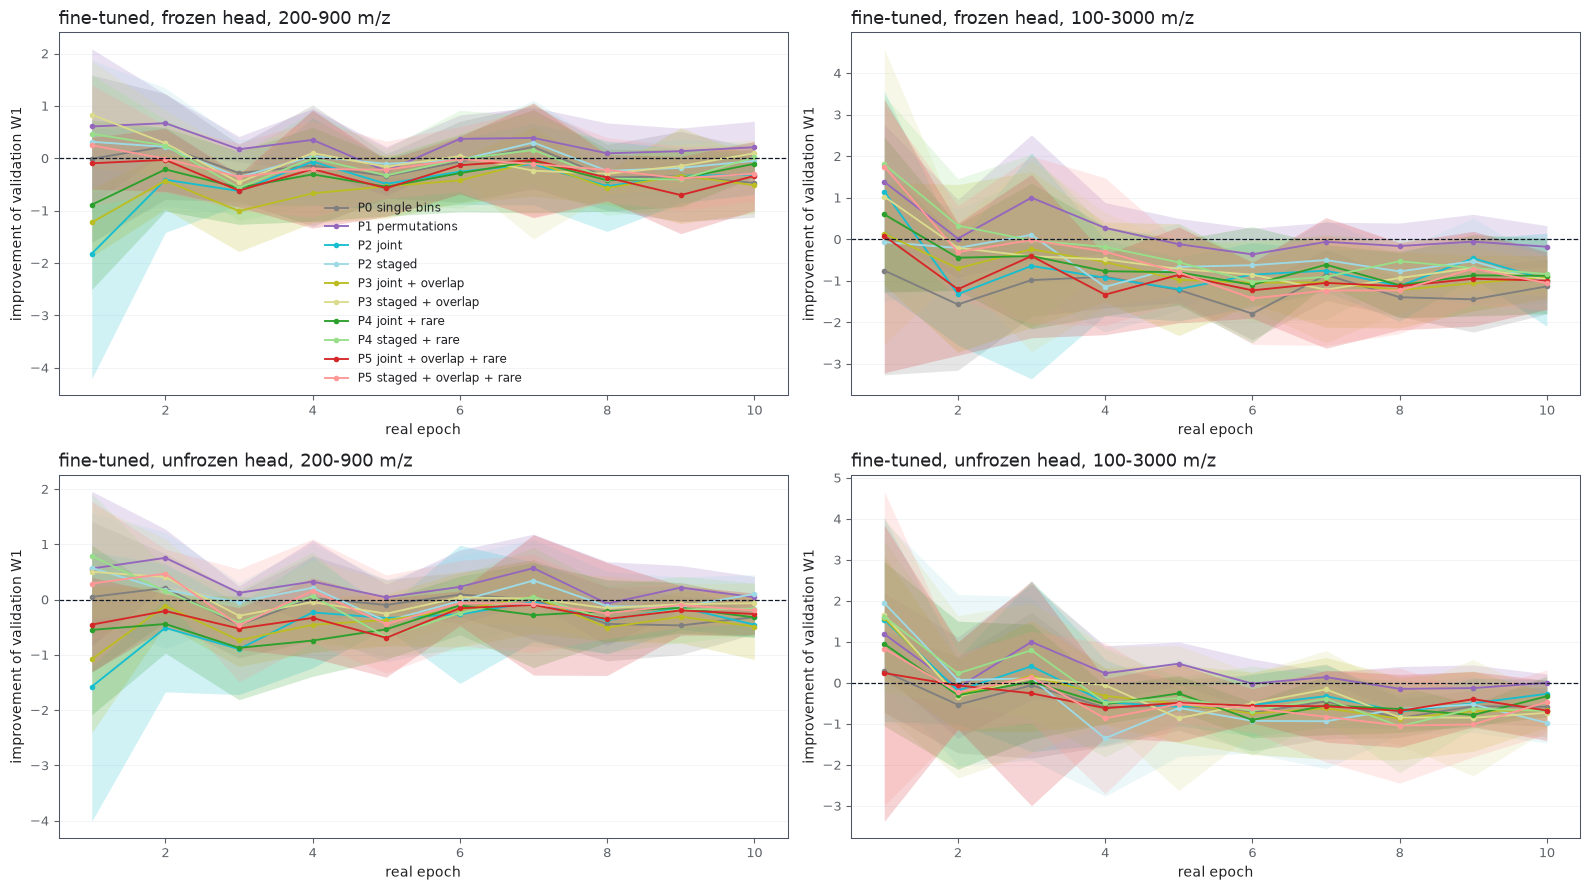

In [4]:
rows = epoch_summary[(epoch_summary.split == 'validation') & (epoch_summary.component == 'masserstein')]
figure, axes = plt.subplots(2, len(AXES), figsize=(8 * len(AXES), 9), dpi=theme.figure_dpi)
for row, stage in enumerate(['frozen_head', 'unfrozen_head']):
    for column, axis in enumerate(AXES):
        figures.epoch_curves(rows[(rows.axis == axis) & (rows.stage == stage)], levels=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                             low='ci_low', high='ci_high', reference=0.0, xlabel='real epoch', ylabel='improvement of validation W1',
                             title=f'{STAGE_LABELS[stage]}, {AXIS_LABELS[axis]}', ax=axes[row, column], theme=theme)
        if (row, column) != (0, 0):
            axes[row, column].get_legend().remove()
figure.tight_layout()
last = epoch_summary[(epoch_summary.split == 'validation') & (epoch_summary.epoch == epoch_summary.epoch.max())]
display(last.assign(result=interval(last)).pivot_table(index='variant', columns=['component', 'axis', 'stage'], values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- axis-100-3000, frozen head: epoch-10 validation W1 improvement -1.13 to -0.18; better than the baseline: none; worse: P0 single bins, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 staged + rare, P5 joint + overlap + rare, P5 staged + overlap + rare.
- axis-100-3000, unfrozen head: epoch-10 validation W1 improvement -0.974 to 0.00171; better than the baseline: none; worse: P0 single bins, P2 staged, P3 joint + overlap, P3 staged + overlap, P4 staged + rare.
- axis-200-900, frozen head: epoch-10 validation W1 improvement -0.514 to 0.212; better than the baseline: none; worse: none.
- axis-200-900, unfrozen head: epoch-10 validation W1 improvement -0.489 to 0.101; better than the baseline: none; worse: P0 single bins, P2 joint.

### Notes

## Were the models still improving at epoch 10?

### Methodology

#### Theoretical

Least-squares slope of the loss over the last three epochs (loss units per epoch). A clearly negative slope
of the validation loss means training stopped before convergence, so a longer run could still change the
comparison. This is the question whether pretraining enables better fine-tuning in a longer run.

#### Implementation

`convergence` (per model, component and split).

#### Figure descriptions

One panel per axis and stage: x = variant (baseline first), one point per repetition, y = slope of the
validation $W_1$. The table gives mean slopes and final values.

slope_last_epochs                                                                       final_value                                                                    
axis                  axis-100-3000               axis-200-900               axis-100-3000 axis-200-900 axis-100-3000               axis-200-900               axis-100-3000 axis-200-900
stage                   frozen_head unfrozen_head  frozen_head unfrozen_head     real_only    real_only   frozen_head unfrozen_head  frozen_head unfrozen_head     real_only    real_only
variant                                                                                                                                                                                  
baseline                        NaN           NaN          NaN           NaN       -0.0156       -0.009           NaN           NaN          NaN           NaN        4.2155       3.5273
P0_single                   -0.1453       -0.1533       0.0430       -0.0696           NaN          NaN        5.3501        4.7971       3.9964        3.8457           NaN          NaN
P1_permutation              -0.0067       -0.0894      -0.0673       -0.0668           NaN          NaN        4.3953        4.2138       3.3158        3.4841           NaN          NaN
P2_joint_base               -0.0906       -0.2312      -0.1183        0.0289           NaN          NaN        5.1899        4.4829       3.8408        3.9810           NaN          NaN
P2_staged_base               0.1157        0.1537      -0.1055       -0.1196           NaN          NaN        5.2520        5.1893       3.5754        3.4263           NaN          NaN
P3_joint_overlap            -0.1717       -0.1212      -0.0357       -0.0178           NaN          NaN        5.1248        4.8750       4.0416        4.0163           NaN          NaN
P3_staged_overlap            0.0007       -0.0706      -0.2048       -0.0544           NaN          NaN        5.1798        4.9460       3.4315        3.5924           NaN          NaN
P4_joint_rare               -0.1290       -0.1714      -0.1657        0.0470           NaN          NaN        5.0950        4.5421       3.6329        3.8498           NaN          NaN
P4_staged_rare               0.1397       -0.2032      -0.2118       -0.1060           NaN          NaN        5.0539        4.8973       3.5090        3.6903           NaN          NaN
P5_joint_all                -0.0833       -0.0198      -0.0249       -0.0541           NaN          NaN        5.2106        4.8891       3.8647        3.7881           NaN          NaN
P5_staged_all               -0.1017       -0.3035       0.0261       -0.0335           NaN          NaN        5.2745        4.6796       3.8208        3.7239           NaN          NaN

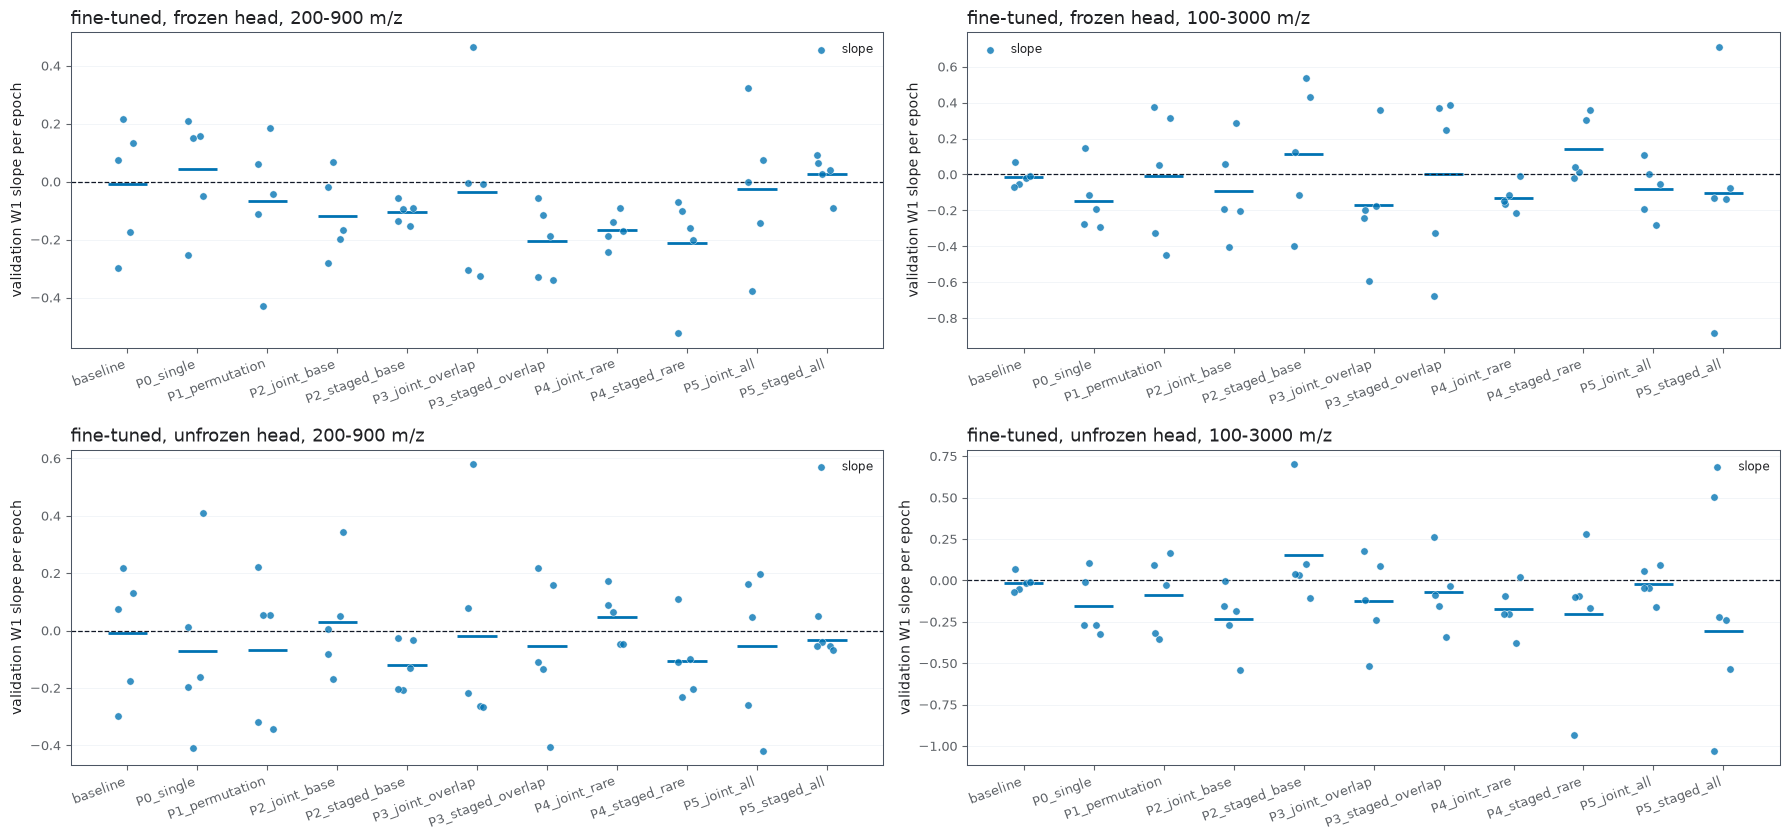

In [5]:
convergence = table('convergence')
slopes = convergence[(convergence.split == 'validation') & (convergence.component == 'masserstein')]
figure, axes = plt.subplots(2, len(AXES), figsize=(9 * len(AXES), 8.5), dpi=theme.figure_dpi)
for row, stage in enumerate(['frozen_head', 'unfrozen_head']):
    for column, axis in enumerate(AXES):
        rows = slopes[(slopes.axis == axis) & slopes.stage.isin([stage, 'real_only'])].assign(kind='slope')
        figures.repetition_points(rows, value='slope_last_epochs', group='variant', hue='kind', order=ORDER, hue_order=['slope'],
                                  colors={'slope': theme.model_palette[0]}, ylabel='validation W1 slope per epoch',
                                  title=f'{STAGE_LABELS[stage]}, {AXIS_LABELS[axis]}', reference=0.0, ax=axes[row, column], theme=theme)
figure.tight_layout()
display(slopes.groupby(['variant', 'axis', 'stage'])[['slope_last_epochs', 'final_value']].mean().unstack(['axis', 'stage']).reindex(ORDER).round(4))

### Remarks

- axis-200-900, frozen head: validation W1 slope over epochs 8-10 -0.21 to 0.043 per epoch (8 of 10 variants steeper than the baseline's -0.009).
- axis-200-900, unfrozen head: validation W1 slope over epochs 8-10 -0.12 to 0.047 per epoch (8 of 10 variants steeper than the baseline's -0.009).
- axis-100-3000, frozen head: validation W1 slope over epochs 8-10 -0.17 to 0.14 per epoch (6 of 10 variants steeper than the baseline's -0.016).
- axis-100-3000, unfrozen head: validation W1 slope over epochs 8-10 -0.3 to 0.15 per epoch (9 of 10 variants steeper than the baseline's -0.016).
- Paired against the baseline of the same repetition, 0 of 40 variant x stage x axis slope differences exclude zero: the per-repetition slopes are too noisy (baseline SD 0.22 on 200-900, 0.055 on 100-3000) to say that any group is still decreasing faster than another.

### Notes

## Epochs needed to reach the baseline's final loss

### Methodology

#### Theoretical

For every fine-tuned model the first epoch at which its loss is at least as good as the final (epoch 10)
loss of the paired baseline; missing when it never gets there within 10 epochs.

#### Implementation

`epochs_to_baseline` (per model, component and split).

#### Figure descriptions

No figure; per variant and stage: number of repetitions that reach the baseline and their mean first epoch.

In [6]:
reach = table('epochs_to_baseline')
reach = reach[reach.split == 'validation']
grouped = reach.groupby(['variant', 'component', 'axis', 'stage']).first_epoch_at_baseline_final
display(pd.concat([grouped.count().rename('reached'), grouped.mean().rename('mean_first_epoch')], axis=1)
        .unstack(['component', 'axis', 'stage']).reindex(VARIANTS))

reached                                                                                                 mean_first_epoch                                           \
component           masserstein                                             total_loss                                               masserstein                                            
axis              axis-100-3000               axis-200-900               axis-100-3000               axis-200-900                  axis-100-3000               axis-200-900                 
stage               frozen_head unfrozen_head  frozen_head unfrozen_head   frozen_head unfrozen_head  frozen_head unfrozen_head      frozen_head unfrozen_head  frozen_head unfrozen_head   
variant                                                                                                                                                                                     
P0_single                     0             1            2             1             0             1            0             1              NaN         10.00       8.0000           8.0   
P1_permutation                5             4            5             5             0             4            2             5              8.0          8.75       8.0000           7.2   
P2_joint_base                 0             1            0             2             0             1            0             2              NaN         10.00          NaN           8.5   
P2_staged_base                0             0            3             4             0             1            0             4              NaN           NaN       8.3333           8.5   
P3_joint_overlap              0             1            1             2             0             1            0             2              NaN          9.00       9.0000           8.5   
P3_staged_overlap             0             1            3             3             0             1            1             3              NaN          9.00       9.3333           8.0   
P4_joint_rare                 0             1            1             1             0             1            0             1              NaN         10.00      10.0000           9.0   
P4_staged_rare                0             0            3             1             0             0            0             1              NaN           NaN       8.6667           7.0   
P5_joint_all                  0             2            1             2             0             2            1             2              NaN          9.00      10.0000           8.0   
P5_staged_all                 0             2            2             2             0             2            0             2              NaN         10.00       8.0000           8.5   

                                                                          
component            total_loss                                           
axis              axis-100-3000               axis-200-900                
stage               frozen_head unfrozen_head  frozen_head unfrozen_head  
variant                                                                   
P0_single                   NaN         10.00          NaN        8.0000  
P1_permutation              NaN          8.75          9.0        7.2000  
P2_joint_base               NaN         10.00          NaN        8.5000  
P2_staged_base              NaN          9.00          NaN        8.5000  
P3_joint_overlap            NaN          9.00          NaN        8.5000  
P3_staged_overlap           NaN          9.00         10.0        8.6667  
P4_joint_rare               NaN         10.00          NaN        9.0000  
P4_staged_rare              NaN           NaN          NaN        7.0000  
P5_joint_all                NaN          9.00         10.0        8.0000  
P5_staged_all               NaN         10.00          NaN        8.5000

### Remarks

- axis-100-3000, frozen head: 5 of 50 fine-tuned models reach the paired baseline's final validation W1 within 10 epochs.
- axis-100-3000, unfrozen head: 13 of 50 fine-tuned models reach the paired baseline's final validation W1 within 10 epochs.
- axis-200-900, frozen head: 21 of 50 fine-tuned models reach the paired baseline's final validation W1 within 10 epochs.
- axis-200-900, unfrozen head: 23 of 50 fine-tuned models reach the paired baseline's final validation W1 within 10 epochs.
- P1 permutations reaches it most often (all five repetitions on 200-900 for both stages).

### Notes

## Results / Summary

### LLM

- **Observed:** a pretrained start gives no lasting advantage in validation W1: at epoch 10 no variant is better than the baseline on either axis and stage, and on 100-3000 five to seven variants are significantly worse. On 100-3000 the unfrozen variants start ahead at epoch 1 (all 10), the lead is gone by epoch 2-4.
- **Observed:** over epochs 8-10 the mean validation W1 of the baseline and of the fine-tuned groups flattens; the per-repetition slopes are noisy and none of the 40 paired slope differences to the baseline excludes zero. Only 5-23 of 50 fine-tuned models per axis and stage reach the paired baseline's final validation W1 within 10 epochs (P1 permutations most often).
- **Interpretation:** at this budget the pretrained start does not accelerate real-data training, and these curves give no evidence that the fine-tuned models would overtake the baseline with more epochs; they do not exclude it either (10 epochs, noisy re-sampled validation). A longer run of both arms remains the only direct test of the "better fine-tuning in a longer run" hypothesis. The recorded validation values are class-balanced re-samples (see the assumptions), so the held-out evaluations of parts 2-5 are the reference for the final metrics.

### Person